In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from spike_lib import TwoSpikes
import two_spikes_th_lib as th

In [13]:
def hist(A, color, labelh = None, line = True):
    eval, _ = np.linalg.eigh(A)

    h = plt.hist(eval, bins = 60, density=True, color= color, alpha = 0.5, label = labelh)
    if line: 
        plt.vlines(eval[-1],ymin = 0, ymax = max(h[0]), color= color, label = "top eigenval")
        plt.vlines(eval[-2],ymin = 0, ymax = max(h[0]), linestyles='--', color= color, label = "Second top eigenval")


In [3]:
def g(N): 
        v = np.random.normal(0, 1, N)
        return v /np.sqrt(N)

In [27]:
N = 1000
lam1 = 2
lam2 = 1.5
rho = 0.2
mu = 1.0

S = TwoSpikes(N, lam1, lam2, rho, mu=mu, alpha=np.sqrt(0.5))

labelh = ['xhat1', 'x1', 'xhat_th', 'm x1']
x1 = S.get_x1()


Pg = (np.eye(N) - np.outer(x1,x1))@g(N)
m = th.overlap_Y_P(lam1)
xhat_th = m*x1 + np.sqrt(1 - m**2) * Pg/np.linalg.norm(Pg)

x1 = [S.compute_theta1(), x1, xhat_th, m*x1]

#get_x1(self)
color = ['b', 'g', 'r', 'y']
#A with x1hat


a_x1= 2*mu*((lam1-1)**2 + 1/N)
a_th = a_x1*m**2
b = lam2
c = 2*mu/N -1

thetas = [th.eigval_Y(a_th,b,rho,c), th.eigval_Y(a_x1,b,rho,c), th.eigval_Y(a_th,b,rho,c), th.eigval_Y(a_th,b,rho,c)  ]




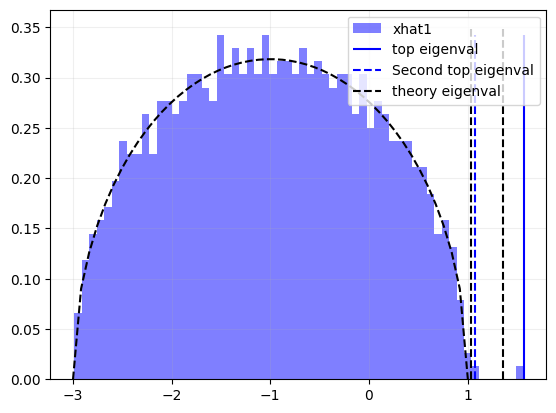

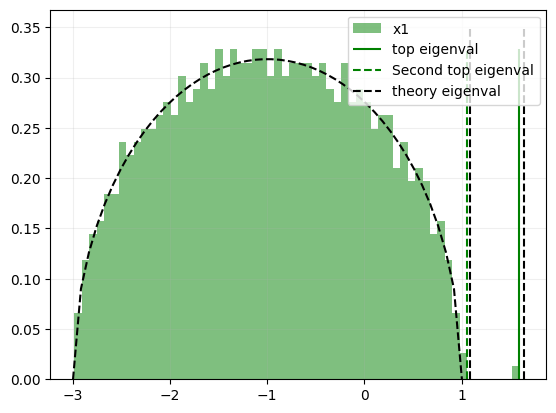

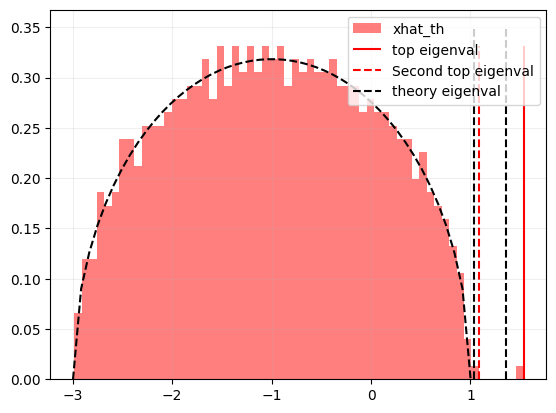

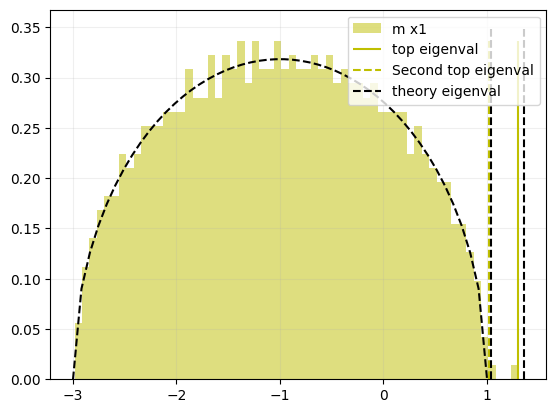

In [28]:
Z = np.linspace(-2,2,50)
for i in range (len(x1)):

    A = S.A(x1[i],mu)
    hist(A, color[i],labelh=labelh[i])

    
    plt.vlines(thetas[i],ymin = 0, ymax = 0.35,  linestyles='--',color= 'k')
    plt.plot(Z +c , th.semi_circle(Z), linestyle='--', color = 'k', label = "theory eigenval")
    plt.legend()
    plt.grid(alpha = 0.2)
    plt.show()

In [ ]:
for i in range (len(x1)):

    A = S.A(x1[i],mu)
    hist(A, color[i],labelh=labelh[i])

plt.legend()
plt.grid(alpha = 0.2)
plt.show()




In [7]:
def comparison1D(vary_param, values, N, lambda1, lambda2, rho, mu,
                 M=5, method=["A"]):
    """Sweep one parameter and measure the recovery quality of each method.

    Parameters
    ----------
    vary_param : str
        Which parameter to sweep: one of {"N", "lambda1", "lambda2",
        "rho", "mu"}.
    values : iterable
        Values taken by ``vary_param``.
    N, lambda1, lambda2, rho, mu : floats
        Default model parameters (the swept one is overwritten).
    M : int
        Number of independent resamples per point (for averaging).
    method : sequence of str
        Subset of {"A", "B", "naive"} to evaluate.
    optimal_mu : bool
        When sweeping something other than mu, if True cross-validate mu at
        each point; otherwise use the equilibrium value mu_eq.

    Returns
    -------
    dict with keys "values" and, per method m, the arrays
        f"{m}_overlap1", f"{m}_overlap1_std",
        f"{m}_overlap2", f"{m}_overlap2_std",
        f"{m}_sum",      f"{m}_sum_std".
    """
    method = list(method)
    out = {"values": np.asarray(values, dtype=float)}
    acc = {m: {"o1": [], "o1s": [], "o2": [], "o2s": [], "s": [], "ss": []}
           for m in method}

    for value in values:
        params = {"N": N, "lambda1": lambda1, "lambda2": lambda2,
                  "rho": rho, "mu": mu}
        params[vary_param] = value


        runs = {m: {"o1": [], "o2": []} for m in method}
        for _ in range(M):
            
            S = TwoSpikes(int(params["N"]), params["lambda1"],
                          params["lambda2"], params["rho"], params["mu"])

            x1 = S.get_x1()
            x_hat = S.compute_theta1()

            Pg = (np.eye(int(params["N"])) - np.outer(x1,x1))@g(int(params["N"]))
            m1 = th.overlap_Y_P(params["lambda1"])

            xhat_th = m1*x1 + np.sqrt(1 - m1**2) * Pg/np.linalg.norm(Pg)
    

            for m in method:
                o1 = abs(x_hat.dot(xhat_th))
                o2 = abs(x_hat.dot(m1*x1))
                runs[m]["o1"].append(o1)
                runs[m]["o2"].append(o2)

        for m in method:
            o1 = np.array(runs[m]["o1"])
            o2 = np.array(runs[m]["o2"])
            s = 0.5 * (o1 + o2)
            acc[m]["o1"].append(o1.mean())
            acc[m]["o1s"].append(o1.std() / np.sqrt(M))
            acc[m]["o2"].append(o2.mean())
            acc[m]["o2s"].append(o2.std() / np.sqrt(M))
            acc[m]["s"].append(s.mean())
            acc[m]["ss"].append(s.std() / np.sqrt(M))

    for m in method:
        out[f"{m}_overlap1"] = np.array(acc[m]["o1"])
        out[f"{m}_overlap1_std"] = np.array(acc[m]["o1s"])
        out[f"{m}_overlap2"] = np.array(acc[m]["o2"])
        out[f"{m}_overlap2_std"] = np.array(acc[m]["o2s"])
        out[f"{m}_sum"] = np.array(acc[m]["s"])
        out[f"{m}_sum_std"] = np.array(acc[m]["ss"])

    return out

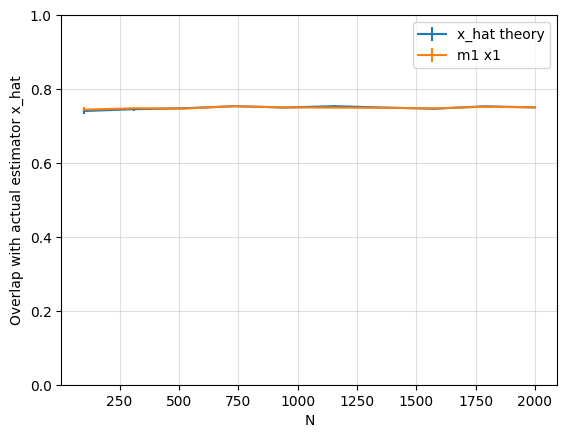

In [11]:
N =np.linspace(100, 2000, 10, dtype=int)
n = 500
LAM = np.linspace(0,4, 15)
lam1 = 2
lam2 = 3
rho = 0.2
mu = 1.0
vary_param = "N"
values = N
out = comparison1D(vary_param, values, n, lam1, lam2, rho, mu,
                 M=20)
plt.errorbar(N,out["A_overlap1"], yerr= out["A_overlap1_std"], label = "x_hat theory")
plt.errorbar(N, out["A_overlap2"], yerr= out["A_overlap2_std"], label = "m1 x1")
plt.ylim((0,1))
plt.grid(alpha = 0.4)
plt.xlabel(vary_param)
plt.ylabel("Overlap with actual estimator x_hat")
plt.legend()
plt.show()
